# [вычищено перед публикацией: команда копирования результатов с HPC,
#  содержала реквизиты доступа к кластеру]


## 1. Setup

In [19]:
import json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

warnings.filterwarnings('ignore')
ROOT = Path('.').resolve()
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (11, 4), 'axes.grid': True,
                     'grid.alpha': 0.25, 'font.size': 9})
CMAP = 'viridis'

def have(p):
    ok = (ROOT / p).exists()
    print(('  OK   ' if ok else '  MISSING ') + p)
    return ok

HAS_RAW     = have('train.parquet')
HAS_EXTRACT = have('reports/local_extract.parquet')
HAS_IMP     = have('reports/local_importance.csv')
HAS_META    = have('reports/local_meta.json')

  OK   train.parquet
  OK   reports/local_extract.parquet
  OK   reports/local_importance.csv
  OK   reports/local_meta.json


In [20]:
# The engineered-feature extract: one row per user at the last validation anchor (2025-10-16),
# `target` = that user's summed GMV over the following 30 days.
if HAS_EXTRACT:
    df = pd.read_parquet('reports/local_extract.parquet')
    FEATURES = [c for c in df.columns
                if c not in ('user_id', 'target', 'gmv_last30', 'gmv_last90', 'ord_last30')]
    df['logt'] = np.log1p(df['target'].clip(lower=0))   # the space the metric lives in
    print(f'{len(df):,} users x {len(FEATURES)} features')
    display(df[['user_id', 'target', 'gmv_last30', 'ord_last30'] + FEATURES[:4]].head())

if HAS_IMP:
    imp = pd.read_csv('reports/local_importance.csv')
    print(f'\nimportance table: {len(imp):,} features, '
          f'{int(imp.beats_null.sum()):,} beat their null')
    display(imp.head(10))

225,431 users x 120 features


,user_id,target,gmv_last30,ord_last30,sbc_dutycycle_ord_180,sbc_histentropy_ord_180,ord_sum_120,sbc_mean_ord_180
0,7,28.615133,31.141647,3.0,0.066667,0.282419,9.0,0.083333
1,15,0.000000,0.000000,0.0,0.005556,0.034390,0.0,0.005556
2,18,227.428085,178.079041,4.0,0.072222,0.321370,18.0,0.111111
3,23,0.000000,0.000000,0.0,0.000000,-0.000000,0.0,0.000000
4,27,19.717396,0.000000,0.0,0.011111,0.061047,0.0,0.011111



importance table: 809 features, 396 beat their null


,feature,gain,null_score,beats_null,in_extract
0,sbc_dutycycle_ord_180,1.212025e+07,9.877957,True,True
1,sbc_histentropy_ord_180,9.201243e+06,9.015443,True,True
2,ord_sum_120,5.121539e+06,8.762693,True,True
3,sbc_mean_ord_180,4.806968e+06,8.964760,True,True
4,sbc_winsorizedmean_gmv_180,4.408281e+06,8.545447,True,True
5,sbc_dutycycle_ord_365,3.003075e+06,9.222741,True,True
6,sbc_mean_ord_365,2.615988e+06,8.537535,True,True
7,sbc_andersondarling_ord_90,2.490113e+06,7.958339,True,True
8,buy_days_180,2.176319e+06,8.661884,True,True
9,sbc_winsorizedmean_gmv_90,1.546709e+06,7.502460,True,True


## 2. Raw events

One row per (user, day) with activity. Note what is **not** here: no product, no price, no
category — the panel is already aggregated to daily counts and sums.

In [21]:
import pyarrow.parquet as pq

pf = pq.ParquetFile('train.parquet')
print(f'rows: {pf.metadata.num_rows:,}   row groups: {pf.metadata.num_row_groups}')
print(pf.schema_arrow)

# 30.6M rows fits in RAM as a few columns; load only what each section needs.
raw = pd.read_parquet('train.parquet',
                      columns=['event_date', 'user_id', 'gmv', 'to_ord', 'to_cart', 'searches'])
raw['event_date'] = pd.to_datetime(raw['event_date'])
print(f"\ndate range : {raw.event_date.min().date()} .. {raw.event_date.max().date()}")
print(f"users      : {raw.user_id.nunique():,}")
print(f"rows/user  : {len(raw) / raw.user_id.nunique():.1f} active days on average")
print(f"total GMV  : {raw.gmv.sum():,.0f}")
raw.describe().T

rows: 30,631,006   row groups: 250
event_date: date32[day]
user_id: int64
search: int64
cat: int64
has_search_to_cart: int64
has_search_to_ord: int64
has_cat_to_cart: int64
has_cat_to_ord: int64
search_to_cart: int64
search_to_ord: int64
cat_to_cart: int64
cat_to_ord: int64
gmv_search: double
gmv_cat: double
to_cart: int64
to_ord: int64
gmv: double
searches: int64

date range : 2025-01-01 .. 2026-02-13
users      : 250,000
rows/user  : 122.5 active days on average
total GMV  : 272,101,574


,count,mean,min,25%,50%,75%,max,std
event_date,30631006,2025-08-12 02:58:11.638972416,2025-01-01 00:00:00,2025-05-04 00:00:00,2025-08-24 00:00:00,2025-11-23 00:00:00,2026-02-13 00:00:00,NaN
user_id,30631006.0,457832.101293,2.0,226535.0,456988.0,688750.0,918481.0,265701.15523
gmv,30631006.0,8.883207,0.0,0.0,0.0,0.0,73830.297037,66.134046
to_ord,30631006.0,0.26287,0.0,0.0,0.0,0.0,138.0,0.890305
to_cart,30631006.0,1.042763,0.0,0.0,0.0,1.0,1535.0,2.574485
searches,30631006.0,3.21434,0.0,1.0,2.0,4.0,630.0,5.101484


## 3. The calendar

Two things to look for:

* **seasonal spikes** — 23 Feb and 8 March are major gifting dates in this market, plus New Year;
* **the guard zone.** Every one of the 250k users is active in *each* of the three 30-day blocks
  ending at the panel's last day. That is a selection rule baked into how the data was sampled,
  not a property of real users. Any anchor whose 30-day target window overlaps it is optimistic
  by ~**+0.041 RMSLE** (`DATA.md` §4), which is why the frozen folds stop at 2025-10-16.

mean daily active users, before vs inside the guard zone:
  before     69,664
  inside     93,425


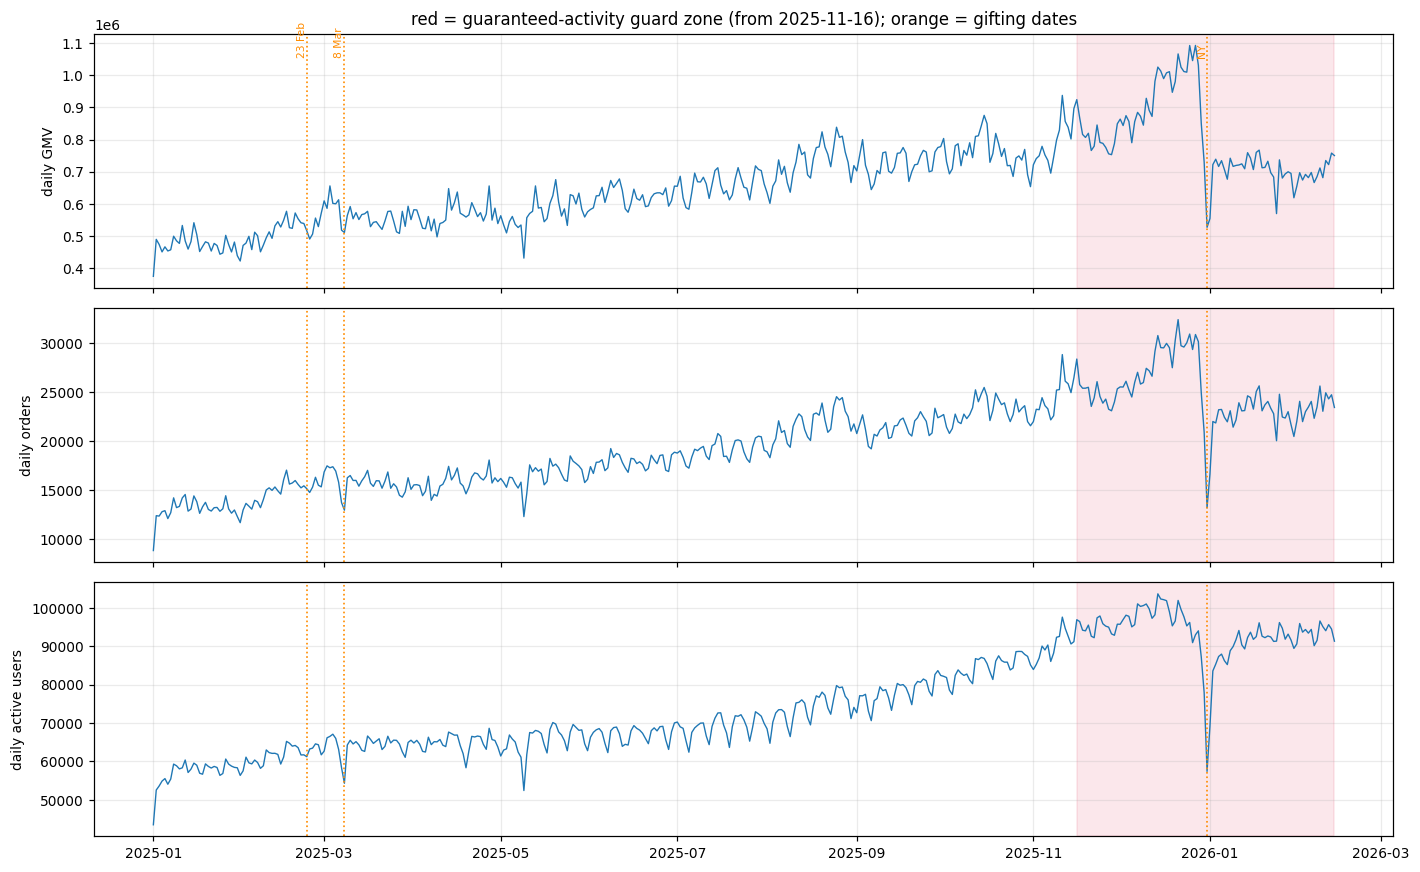

In [22]:
daily = raw.groupby('event_date').agg(gmv=('gmv', 'sum'), orders=('to_ord', 'sum'),
                                      users=('user_id', 'nunique')).reset_index()
meta = json.loads(Path('reports/local_meta.json').read_text()) if HAS_META else {}
guard = pd.Timestamp(meta.get('guard_zone_start', '2025-11-16'))

fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
for ax, col, lab in zip(axes, ['gmv', 'orders', 'users'],
                        ['daily GMV', 'daily orders', 'daily active users']):
    ax.plot(daily.event_date, daily[col], lw=0.9)
    ax.set_ylabel(lab)
    ax.axvspan(guard, daily.event_date.max(), color='crimson', alpha=0.10)
    for d, name in [('2025-02-23', '23 Feb'), ('2025-03-08', '8 Mar'), ('2026-02-23', '23 Feb'),
                    ('2025-12-31', 'NY'), ('2026-03-08', '8 Mar')]:
        d = pd.Timestamp(d)
        if daily.event_date.min() <= d <= daily.event_date.max():
            ax.axvline(d, color='darkorange', ls=':', lw=1.1)
            if col == 'gmv':
                ax.text(d, ax.get_ylim()[1] * 0.94, name, fontsize=7, rotation=90,
                        color='darkorange', ha='right')
axes[0].set_title(f'red = guaranteed-activity guard zone (from {guard.date()}); '
                  f'orange = gifting dates')
plt.tight_layout()

print('mean daily active users, before vs inside the guard zone:')
print(f"  before {daily[daily.event_date < guard].users.mean():>10,.0f}")
print(f"  inside {daily[daily.event_date >= guard].users.mean():>10,.0f}")

### Where the model's predictions sit on this timeline

The calendar above is *actuals*. This adds what the model says. Two things are being shown:

* **OOF fold predictions** — at each frozen fold's validation anchor, the summed prediction over
  that fold's population against the summed truth, plotted at the midpoint of its 30-day target
  window;
* **the test-window prediction** — the total of `subs/*.csv`, sitting past the end of the panel
  over `2026-02-14 … 2026-03-15`, which is never observed.

The context curve is a **30-day rolling sum** of daily GMV, so it is on the same footing as a
30-day target. It covers all users, while the fold aggregates cover only that fold's population
(active in the 30 days before its anchor), so the curve sits a little above the fold truths by
construction.

anchor        population         actual      predicted   ratio
2025-06-18       205,708     18,887,911      7,360,849   0.390
2025-07-18       208,353     20,155,460      7,830,311   0.388
2025-08-17       212,755     21,866,941      8,387,008   0.384
2025-09-16       218,793     22,456,778      9,800,382   0.436
2025-10-16       225,431     22,623,028      9,989,717   0.442

e0049 test-window prediction:     10,694,784
e0060 test-window prediction:     10,758,275
e0064 test-window prediction:     10,565,132


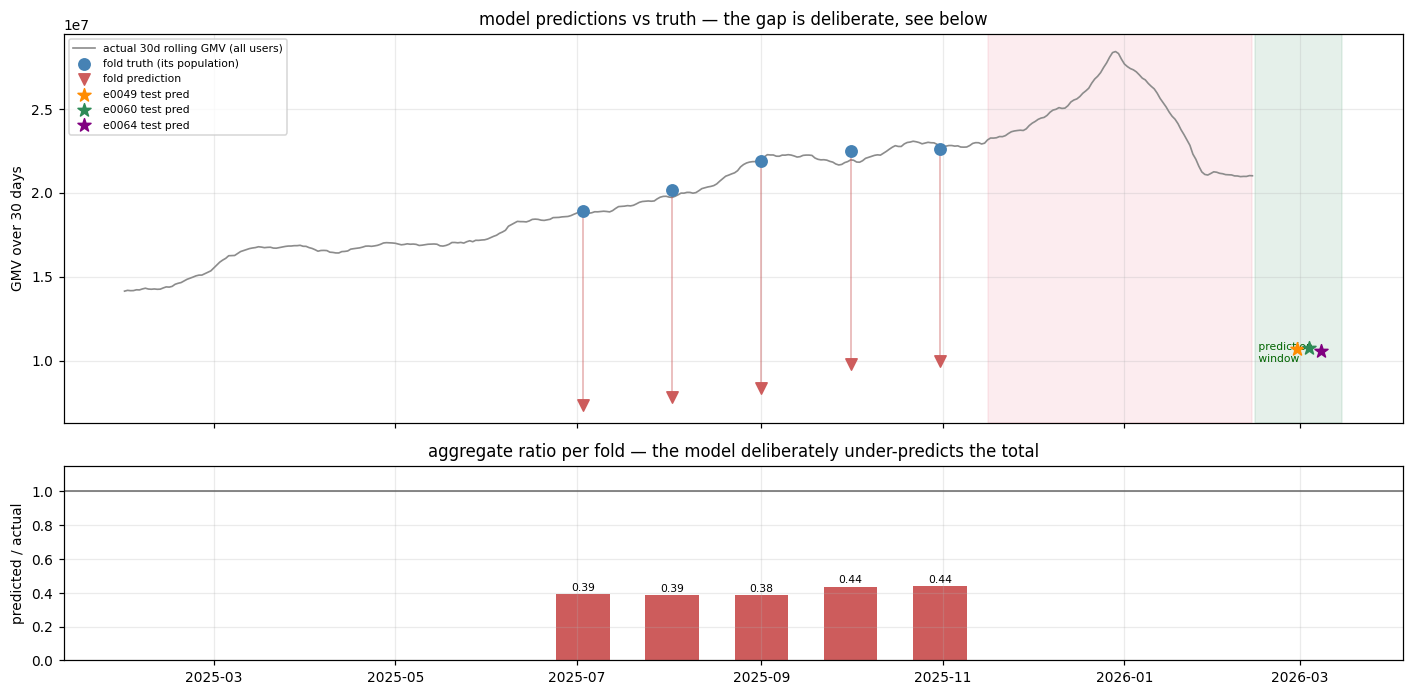

In [23]:
# --- model predictions on the calendar --------------------------------------------------
oof = pd.read_parquet('reports/e0049.parquet')
agg = (oof.groupby('anchor_date')
          .agg(n=('user_id', 'size'), true=('y_true', 'sum'), pred=('y_pred', 'sum'))
          .reset_index())
agg['anchor'] = pd.to_datetime(agg.anchor_date)
agg['mid']    = agg.anchor + pd.Timedelta(days=15)      # midpoint of the 30d target window
agg['ratio']  = agg.pred / agg.true

roll = daily.set_index('event_date').gmv.rolling(30).sum()   # comparable to a 30d target

subs = {}
for tag in ['e0049', 'e0060', 'e0064']:
    try:
        subs[tag] = pd.read_csv(f'subs/{tag}.csv').predict.sum()
    except FileNotFoundError:
        pass
TEST_MID = pd.Timestamp('2026-02-28')                        # midpoint of 2026-02-14..03-15

fig, ax = plt.subplots(2, 1, figsize=(13, 6.4), sharex=True,
                       gridspec_kw={'height_ratios': [2, 1]})

ax[0].plot(roll.index, roll.values, color='0.55', lw=1.1, label='actual 30d rolling GMV (all users)')
ax[0].scatter(agg.mid, agg.true, s=55, color='steelblue', zorder=5, label='fold truth (its population)')
ax[0].scatter(agg.mid, agg.pred, s=55, marker='v', color='indianred', zorder=5, label='fold prediction')
for _, r in agg.iterrows():
    ax[0].plot([r['mid'], r['mid']], [r.pred, r.true], color='indianred', lw=1, alpha=0.5)
for i, (tag, tot) in enumerate(subs.items()):
    ax[0].scatter([TEST_MID + pd.Timedelta(days=i*4)], [tot], s=80, marker='*',
                  color=['darkorange', 'seagreen', 'purple'][i % 3], zorder=6, label=f'{tag} test pred')
ax[0].axvspan(guard, pd.Timestamp('2026-02-13'), color='crimson', alpha=0.08)
ax[0].axvspan(pd.Timestamp('2026-02-14'), pd.Timestamp('2026-03-15'), color='seagreen', alpha=0.12)
ax[0].text(pd.Timestamp('2026-02-14'), roll.max()*0.35, ' prediction\n window', fontsize=7, color='darkgreen')
ax[0].set_ylabel('GMV over 30 days'); ax[0].legend(fontsize=7, loc='upper left')
ax[0].set_title('model predictions vs truth — the gap is deliberate, see below')

ax[1].bar(agg.mid, agg.ratio, width=18, color='indianred')
ax[1].axhline(1.0, color='0.4', lw=1)
for _, r in agg.iterrows():
    ax[1].text(r['mid'], r.ratio + 0.02, f'{r.ratio:.2f}', ha='center', fontsize=7)
ax[1].set_ylim(0, 1.15); ax[1].set_ylabel('predicted / actual')
ax[1].set_title('aggregate ratio per fold — the model deliberately under-predicts the total')
plt.tight_layout()

print(f"{'anchor':12s} {'population':>11s} {'actual':>14s} {'predicted':>14s} {'ratio':>7s}")
for _, r in agg.iterrows():
    print(f"{str(r.anchor.date()):12s} {r.n:>11,} {r.true:>14,.0f} {r.pred:>14,.0f} {r.ratio:>7.3f}")
print()
for tag, tot in subs.items():
    print(f"{tag} test-window prediction: {tot:>14,.0f}")

**The model predicts ~40% of the actual total, on every fold, and does it on purpose.**

That is not a bug and it must not be "fixed". RMSLE decomposes as

$$(\sigma_L-\sigma_M)^2 + 2\sigma_L\sigma_M(1-\rho) + (\bar L-\bar M)^2$$

and §12.2 measured the level term at **0.01% of the score**. Optimising RMSLE pushes predictions
toward the *conditional median* in log space, and with ~43% of targets exactly zero that median
sits far below the mean. `src/calibrate.py` searched for a correction and found `k* = 1.000`;
forcing the aggregate to match reality costs **+0.163 RMSLE** (`DATA.md` §8.4).

So the ratio panel is a diagnostic of *consistency*, not of accuracy — what matters is that it is
stable (0.38–0.44) rather than drifting. A sudden move there would signal a real problem.

### Day-of-week and month effects

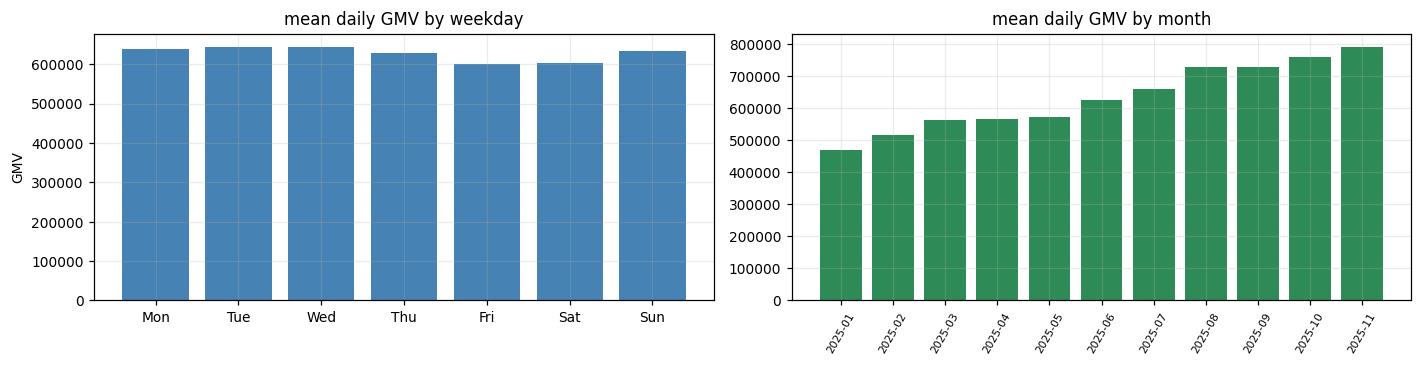

In [24]:
d2 = daily[daily.event_date < guard].copy()
d2['dow'] = d2.event_date.dt.dayofweek
d2['month'] = d2.event_date.dt.to_period('M').astype(str)
fig, ax = plt.subplots(1, 2, figsize=(13, 3.4))
g = d2.groupby('dow').gmv.mean()
ax[0].bar(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], g.values, color='steelblue')
ax[0].set_title('mean daily GMV by weekday'); ax[0].set_ylabel('GMV')
m = d2.groupby('month').gmv.mean()
ax[1].bar(range(len(m)), m.values, color='seagreen')
ax[1].set_xticks(range(len(m))); ax[1].set_xticklabels(m.index, rotation=60, fontsize=7)
ax[1].set_title('mean daily GMV by month')
plt.tight_layout()

## 4. Per-user sparsity — the defining property of this dataset

Most users barely appear. This is why counting features (`buy_days_180`, `ord_sum_120`) dominate
the importance table over anything clever about amounts.

users with 0 lifetime orders :  12.3%
users with 0 lifetime GMV    :  12.3%
median active days           : 102 of 409
top  1% of users hold 14.9% of all GMV
top 10% of users hold 53.0% of all GMV


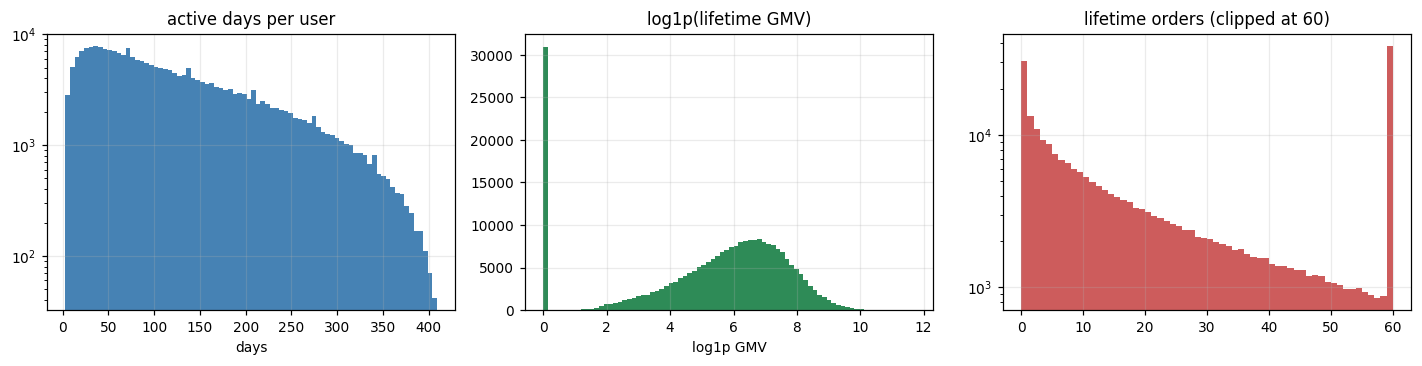

In [25]:
per_user = raw.groupby('user_id').agg(active_days=('event_date', 'nunique'),
                                      gmv=('gmv', 'sum'), orders=('to_ord', 'sum'))
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
ax[0].hist(per_user.active_days, bins=80, color='steelblue')
ax[0].set_yscale('log'); ax[0].set_title('active days per user'); ax[0].set_xlabel('days')
ax[1].hist(np.log1p(per_user.gmv), bins=80, color='seagreen')
ax[1].set_title('log1p(lifetime GMV)'); ax[1].set_xlabel('log1p GMV')
ax[2].hist(per_user.orders.clip(upper=60), bins=60, color='indianred')
ax[2].set_yscale('log'); ax[2].set_title('lifetime orders (clipped at 60)')
plt.tight_layout()

print(f"users with 0 lifetime orders : {(per_user.orders == 0).mean():6.1%}")
print(f"users with 0 lifetime GMV    : {(per_user.gmv <= 0).mean():6.1%}")
print(f"median active days           : {per_user.active_days.median():.0f} of 409")
sh = per_user.gmv.sort_values(ascending=False).cumsum() / per_user.gmv.sum()
print(f"top  1% of users hold {sh.iloc[int(0.01 * len(sh))]:.1%} of all GMV")
print(f"top 10% of users hold {sh.iloc[int(0.10 * len(sh))]:.1%} of all GMV")

## 5. The target

`target` = sum of `gmv` over the 30 days *after* the anchor, for users active in the 30 days
*before* it. Roughly **43% are zero** — a point mass the model must handle, and the reason a
two-part/hurdle formulation keeps looking tempting (its oracle bound is 0.983 against our 1.766).

zero share      :  42.8%
mean / median   : 100.4 / 13.1
sd of log1p     : 2.3417   <- RMSLE is bounded by this
q99 / max       : 1,206 / 23,055


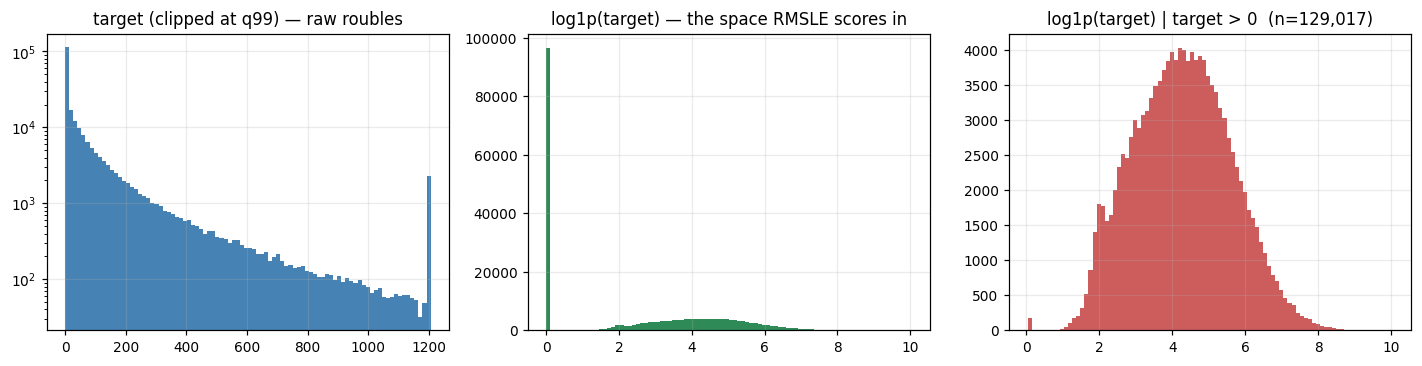

In [26]:
if HAS_EXTRACT:
    fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
    ax[0].hist(df.target.clip(upper=df.target.quantile(0.99)), bins=90, color='steelblue')
    ax[0].set_yscale('log'); ax[0].set_title('target (clipped at q99) — raw roubles')
    ax[1].hist(df.logt, bins=90, color='seagreen')
    ax[1].set_title('log1p(target) — the space RMSLE scores in')
    nz = df.logt[df.target > 0]
    ax[2].hist(nz, bins=90, color='indianred')
    ax[2].set_title(f'log1p(target) | target > 0  (n={len(nz):,})')
    plt.tight_layout()

    print(f"zero share      : {(df.target <= 0).mean():6.1%}")
    print(f"mean / median   : {df.target.mean():,.1f} / {df.target.median():,.1f}")
    print(f"sd of log1p     : {df.logt.std():.4f}   <- RMSLE is bounded by this")
    print(f"q99 / max       : {df.target.quantile(0.99):,.0f} / {df.target.max():,.0f}")

## 6. Why the metric is the whole game

Write `L = log1p(y_true)`, `M = log1p(y_pred)`. Then

$$\text{RMSLE}^2 = (\sigma_L-\sigma_M)^2 \;+\; 2\,\sigma_L\sigma_M(1-\rho) \;+\; (\bar L-\bar M)^2$$

The middle term dominates: **the only lever that matters is correlation in log space.** The
level term is worth ~0.006 of a ~2.1 total, which is why calibration is useless here (`k* = 1.000`)
and why forcing the aggregate to match reality costs **+0.163**. Change `rho` below and watch.

In [27]:
def rmsle(y_true, y_pred):
    """The frozen competition metric (src/metrics.py). Only predictions are clipped."""
    return float(np.sqrt(np.mean(
        (np.log1p(np.asarray(y_true, float)) -
         np.log1p(np.maximum(np.asarray(y_pred, float), 0.0))) ** 2)))

def decompose(y_true, y_pred):
    L = np.log1p(np.asarray(y_true, float))
    M = np.log1p(np.maximum(np.asarray(y_pred, float), 0.0))
    sL, sM, rho = L.std(), M.std(), float(np.corrcoef(L, M)[0, 1])
    return {'rmsle': rmsle(y_true, y_pred), 'sd_true': sL, 'sd_pred': sM, 'corr': rho,
            'term_sd': (sL - sM) ** 2, 'term_corr': 2 * sL * sM * (1 - rho),
            'term_mean': (L.mean() - M.mean()) ** 2}

if HAS_EXTRACT:
    print('naive baselines on this anchor:')
    for name, pred in [('all zeros', np.zeros(len(df))),
                       ('constant = median', np.full(len(df), df.target.median())),
                       ('last-30d GMV', df.gmv_last30.values),
                       ('geometric-ish (0.5 x last30)', 0.5 * df.gmv_last30.values)]:
        print(f'  {name:30s} RMSLE = {rmsle(df.target.values, pred):.5f}')

    print('\ndecomposition of the last-30d baseline:')
    for k, v in decompose(df.target.values, df.gmv_last30.values).items():
        print(f'  {k:12s} {v:>10.5f}')

    # how much would a given log-space correlation buy?
    sL = df.logt.std()
    print('\nbest achievable RMSLE as a function of log-space correlation (sd matched):')
    for r in [0.5, 0.6, 0.7, 0.8, 0.9, 0.95]:
        print(f'  corr={r:.2f} -> {np.sqrt(2 * sL * sL * (1 - r)):.4f}')

naive baselines on this anchor:
  all zeros                      RMSLE = 3.38314
  constant = median              RMSLE = 2.35074
  last-30d GMV                   RMSLE = 2.21529
  geometric-ish (0.5 x last30)   RMSLE = 2.11828

decomposition of the last-30d baseline:
  rmsle           2.21529
  sd_true         2.34169
  sd_pred         2.34971
  corr            0.55406
  term_sd         0.00006
  term_corr       4.90736
  term_mean       0.00009

best achievable RMSLE as a function of log-space correlation (sd matched):
  corr=0.50 -> 2.3417
  corr=0.60 -> 2.0945
  corr=0.70 -> 1.8139
  corr=0.80 -> 1.4810
  corr=0.90 -> 1.0472
  corr=0.95 -> 0.7405


## 7. The CV scheme

Expanding-window rolling origin, 5 folds, **frozen** in `data/folds.parquet`. Each fold trains on
weekly anchors and validates 30 days later; the 30-day gap is the embargo that stops a training
row's target window from overlapping the validation anchor's features.

  fold 0:  8 train anchors, valid 2025-06-18
  fold 1: 12 train anchors, valid 2025-07-18
  fold 2: 16 train anchors, valid 2025-08-17
  fold 3: 20 train anchors, valid 2025-09-16
  fold 4: 25 train anchors, valid 2025-10-16


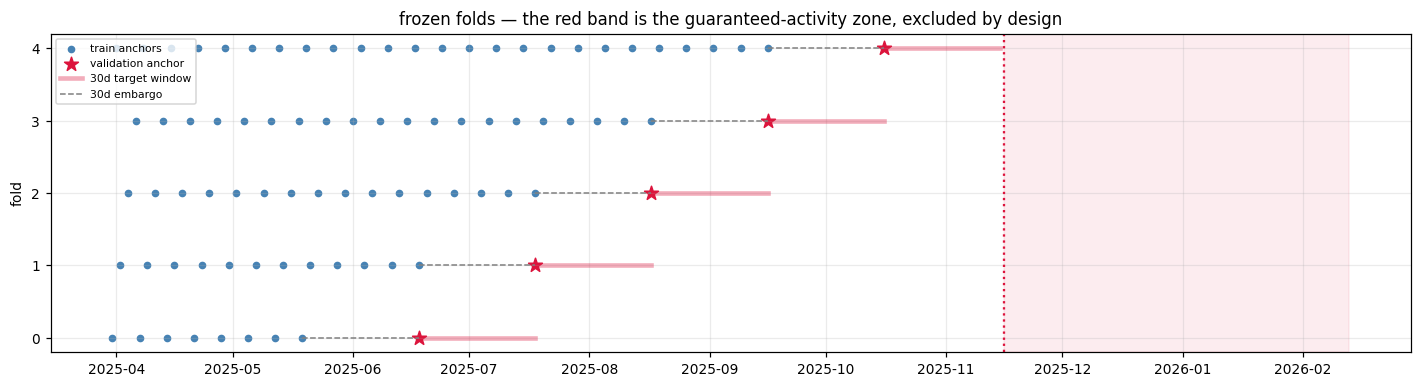

In [28]:
if HAS_META:
    fig, ax = plt.subplots(figsize=(13, 3.6))
    for k, f in enumerate(meta['folds']):
        ta = [pd.Timestamp(x) for x in f['train_anchors']]
        va = pd.Timestamp(f['valid_anchor'])
        ax.scatter(ta, [k] * len(ta), s=16, color='steelblue',
                   label='train anchors' if k == 0 else None)
        ax.scatter([va], [k], s=90, marker='*', color='crimson',
                   label='validation anchor' if k == 0 else None)
        ax.plot([va, va + pd.Timedelta(days=30)], [k, k], color='crimson', lw=3, alpha=0.35,
                label='30d target window' if k == 0 else None)
        ax.plot([ta[-1], va], [k, k], color='grey', ls='--', lw=1,
                label='30d embargo' if k == 0 else None)
    ax.axvline(pd.Timestamp(meta['guard_zone_start']), color='crimson', ls=':')
    ax.axvspan(pd.Timestamp(meta['guard_zone_start']), pd.Timestamp(meta['panel_end']),
               color='crimson', alpha=0.08)
    ax.set_yticks(range(len(meta['folds']))); ax.set_ylabel('fold')
    ax.set_title('frozen folds — the red band is the guaranteed-activity zone, excluded by design')
    ax.legend(fontsize=7, loc='upper left')
    plt.tight_layout()
    for k, f in enumerate(meta['folds']):
        print(f"  fold {k}: {len(f['train_anchors']):>2} train anchors, "
              f"valid {f['valid_anchor']}")

## 8. One feature against the target

Change `FEAT`. Binned means are the honest view — a scatter of 225k users overplots so badly that
whichever point is drawn last owns the pixel.

Spearman vs log1p(target): +0.6343


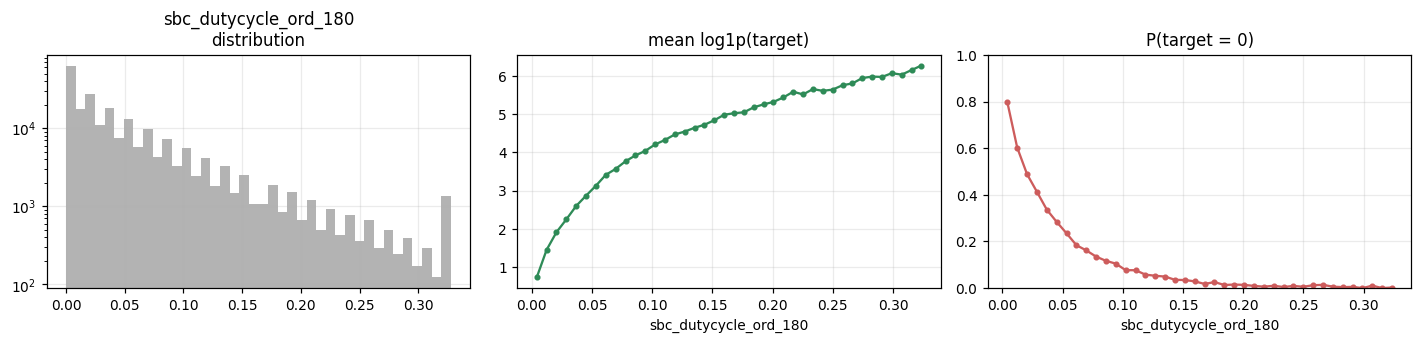

In [29]:
def feature_vs_target(feat, bins=40, min_n=50):
    x = df[feat].values
    lo, hi = np.percentile(x, [0.5, 99.5])
    if hi <= lo:
        hi = lo + 1e-9
    edges = np.linspace(lo, hi, bins + 1)
    idx = np.clip(np.digitize(x, edges) - 1, 0, bins - 1)
    cnt = np.bincount(idx, minlength=bins)
    mean_logt = np.bincount(idx, weights=df.logt.values, minlength=bins) / np.maximum(cnt, 1)
    p_zero = np.bincount(idx, weights=(df.target.values <= 0).astype(float),
                         minlength=bins) / np.maximum(cnt, 1)
    mid = (edges[:-1] + edges[1:]) / 2
    ok = cnt >= min_n

    fig, ax = plt.subplots(1, 3, figsize=(13, 3.2))
    ax[0].hist(np.clip(x, lo, hi), bins=bins, color='0.7'); ax[0].set_yscale('log')
    ax[0].set_title(f'{feat}\ndistribution')
    ax[1].plot(mid[ok], mean_logt[ok], 'o-', ms=3, color='seagreen')
    ax[1].set_title('mean log1p(target)'); ax[1].set_xlabel(feat)
    ax[2].plot(mid[ok], p_zero[ok], 'o-', ms=3, color='indianred')
    ax[2].set_title('P(target = 0)'); ax[2].set_xlabel(feat); ax[2].set_ylim(0, 1)
    plt.tight_layout()
    print(f'Spearman vs log1p(target): '
          f'{pd.Series(x).corr(df.logt, method="spearman"):+.4f}')

FEAT = FEATURES[0] if HAS_EXTRACT else None
if FEAT:
    feature_vs_target(FEAT)

## 9. The pair grid

Same code that produced `reports/eda/pairgrid_*.png`, shrunk so it renders in seconds. Cell (i, j)
is feature *j* on x against feature *i* on y; colour is the target. Grey diagonal cells show the
feature against the target instead of a useless y=x line.

Two deliberate choices, both of which would hide the structure if taken naively:
* **colour on `log1p(target)`** — GMV spans five orders of magnitude, so a linear colour scale
  makes 99% of users one flat shade;
* **axes clipped to [q0.5, q99.5]** — one user with 400 orders otherwise squashes everyone else
  into a single pixel column.

`mode='binned'` colours each cell by the **mean** target of the users in it (the honest view of
where the target lives); `mode='scatter'` draws individual users in shuffled order (better for
spotting outliers and cluster shapes).

index -> feature
   1  sbc_dutycycle_ord_180
   2  sbc_histentropy_ord_180
   3  ord_sum_120
   4  sbc_mean_ord_180
   5  sbc_winsorizedmean_gmv_180
   6  sbc_dutycycle_ord_365
   7  sbc_mean_ord_365
   8  sbc_andersondarling_ord_90


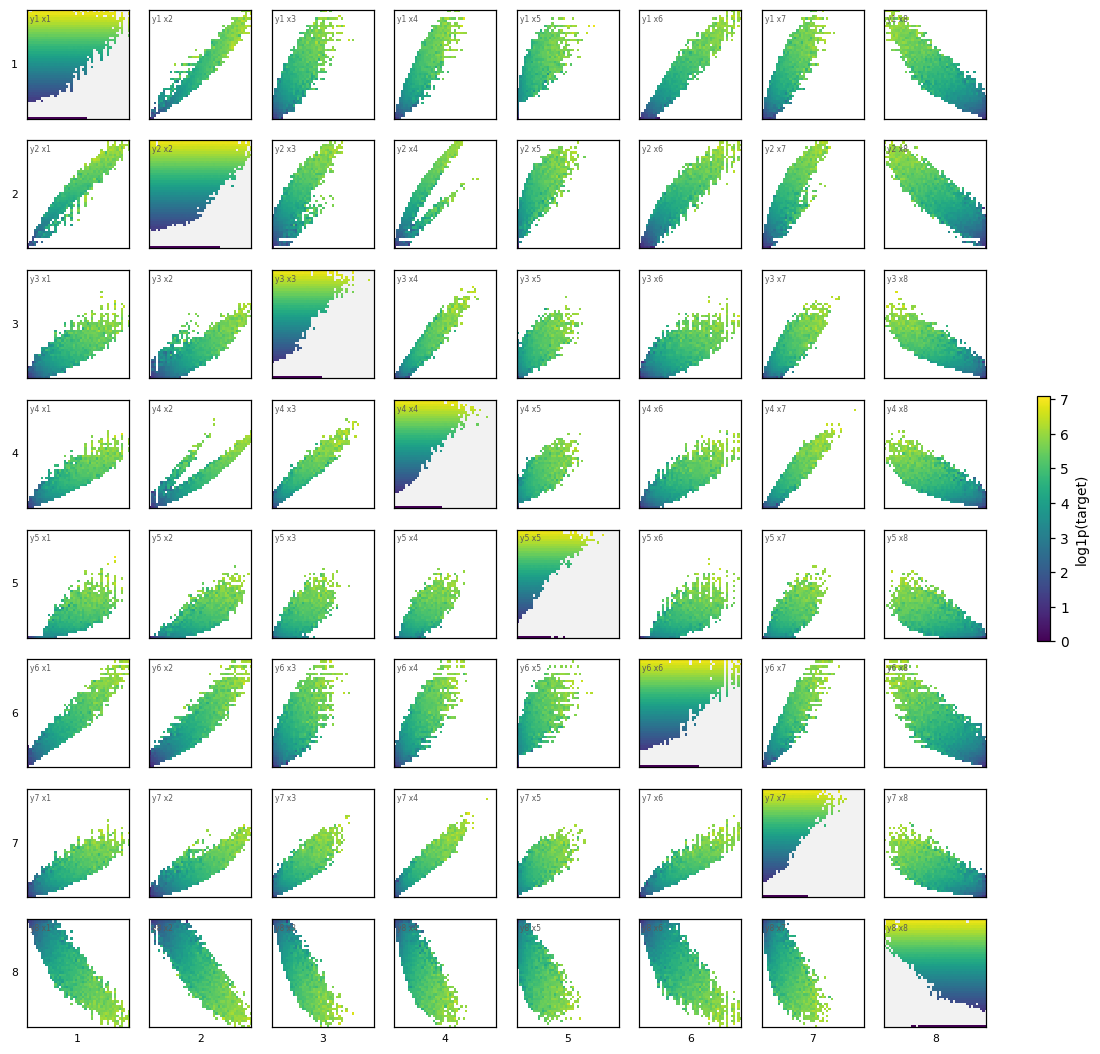

In [30]:
def pair_grid(feats, mode='binned', bins=45, min_bin_n=12, n_points=6000,
              panel_in=1.5, marker=1.2, seed=0):
    """k x k pair grid coloured by log1p(target). Pass any list of column names."""
    K = len(feats)
    F = df[feats].to_numpy(np.float64)
    F = np.nan_to_num(F, nan=0.0, posinf=0.0, neginf=0.0)
    L = df.logt.values
    lo = np.percentile(F, 0.5, axis=0)
    hi = np.percentile(F, 99.5, axis=0)
    hi = np.where(hi <= lo, lo + 1e-9, hi)
    norm = Normalize(vmin=float(np.percentile(L, 1)), vmax=float(np.percentile(L, 99)))

    rng = np.random.default_rng(seed)
    samp = rng.permutation(rng.choice(len(F), min(n_points, len(F)), replace=False))

    fig, axes = plt.subplots(K, K, figsize=(K * panel_in, K * panel_in))
    axes = np.atleast_2d(axes)
    for i in range(K):
        for j in range(K):
            ax = axes[i, j]
            yv = L if i == j else F[:, i]
            ylo, yhi = (norm.vmin, norm.vmax) if i == j else (lo[i], hi[i])
            if mode == 'binned':
                xe = np.linspace(lo[j], hi[j], bins + 1)
                ye = np.linspace(ylo, yhi, bins + 1)
                cnt, _, _ = np.histogram2d(F[:, j], yv, bins=[xe, ye])
                tot, _, _ = np.histogram2d(F[:, j], yv, bins=[xe, ye], weights=L)
                m = np.where(cnt >= min_bin_n, tot / np.maximum(cnt, 1), np.nan)
                ax.imshow(m.T, origin='lower', aspect='auto', cmap=CMAP, norm=norm,
                          extent=[lo[j], hi[j], ylo, yhi], interpolation='nearest')
            else:
                ax.scatter(F[samp, j], yv[samp], s=marker, c=L[samp], cmap=CMAP, norm=norm,
                           linewidths=0, alpha=0.5, rasterized=True)
                ax.set_xlim(lo[j], hi[j]); ax.set_ylim(ylo, yhi)
            if i == j:
                ax.set_facecolor('#f2f2f2')
            ax.set_xticks([]); ax.set_yticks([])
            ax.text(0.03, 0.96, f'y{i+1} x{j+1}', transform=ax.transAxes, fontsize=5,
                    va='top', color='0.35')
            if j == 0:
                ax.set_ylabel(f'{i+1}', fontsize=7, rotation=0, labelpad=8, va='center')
            if i == K - 1:
                ax.set_xlabel(f'{j+1}', fontsize=7)
    fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=CMAP),
                 ax=axes, fraction=0.012, label='log1p(target)')
    print('index -> feature')
    for r, n in enumerate(feats, 1):
        print(f'  {r:>2}  {n}')
    return fig

if HAS_EXTRACT:
    _ = pair_grid(FEATURES[:8], mode='binned')

index -> feature
   1  sbc_dutycycle_ord_180
   2  sbc_histentropy_ord_180
   3  ord_sum_120
   4  sbc_mean_ord_180
   5  sbc_winsorizedmean_gmv_180
   6  sbc_dutycycle_ord_365
   7  sbc_mean_ord_365
   8  sbc_andersondarling_ord_90


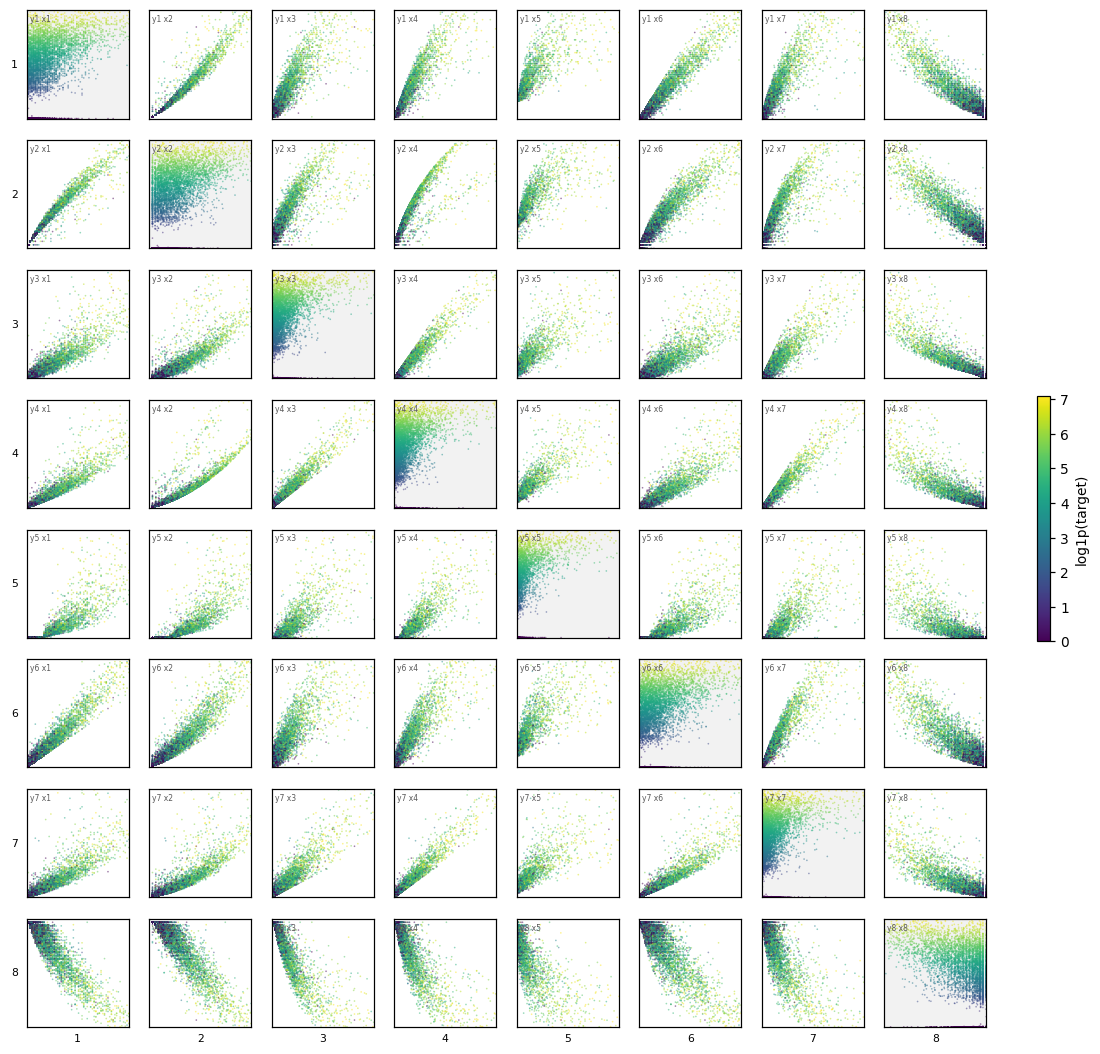

In [31]:
# The scatter view of the same features. Swap in any columns you like, e.g.
#   pair_grid(['buy_days_180', 'ord_sum_120', 'gmv_last30', 'srch_sum_14'], mode='scatter')
if HAS_EXTRACT:
    _ = pair_grid(FEATURES[:8], mode='scatter', n_points=8000)

## 10. Feature correlation

Worth a look: dropping the entire `sbcmoment` family — which contains the single highest-gain
feature in the model (`sbc_dutycycle_ord_180`, 12.1M gain, 2.4× the next) — changed CV by
**−0.00008**, i.e. nothing. That is what severe redundancy looks like, and it is exactly what
gain importance cannot see.

most redundant pairs:
  1.000  sbc_dutycycle_ord_365  <->  buy_days_365
  1.000  sbc_dutycycle_ord_180  <->  buy_days_180
  1.000  sbc_mean_ord_365  <->  sbc_mad_ord_365
  0.999  sbc_mean_ord_180  <->  sbc_mad_ord_180
  0.999  sbc_fracup_gmv_365  <->  sbc_fracup_ord_365
  0.999  buy_days_365  <->  sbc_fracup_gmv_365
  0.999  sbc_dutycycle_ord_365  <->  sbc_fracup_gmv_365
  0.998  buy_days_180  <->  sbc_fracup_gmv_180
  0.998  sbc_dutycycle_ord_180  <->  sbc_fracup_gmv_180
  0.998  buy_days_365  <->  sbc_fracup_ord_365
  0.998  sbc_dutycycle_ord_365  <->  sbc_fracup_ord_365
  0.996  sbc_mean_ord_180  <->  pct_ord_180
  0.996  buy_days_90  <->  sbc_histentropy_ord_90
  0.996  sbc_andersondarling_ord_90  <->  sbc_histentropy_ord_90
  0.996  sbc_mad_ord_180  <->  pct_ord_180


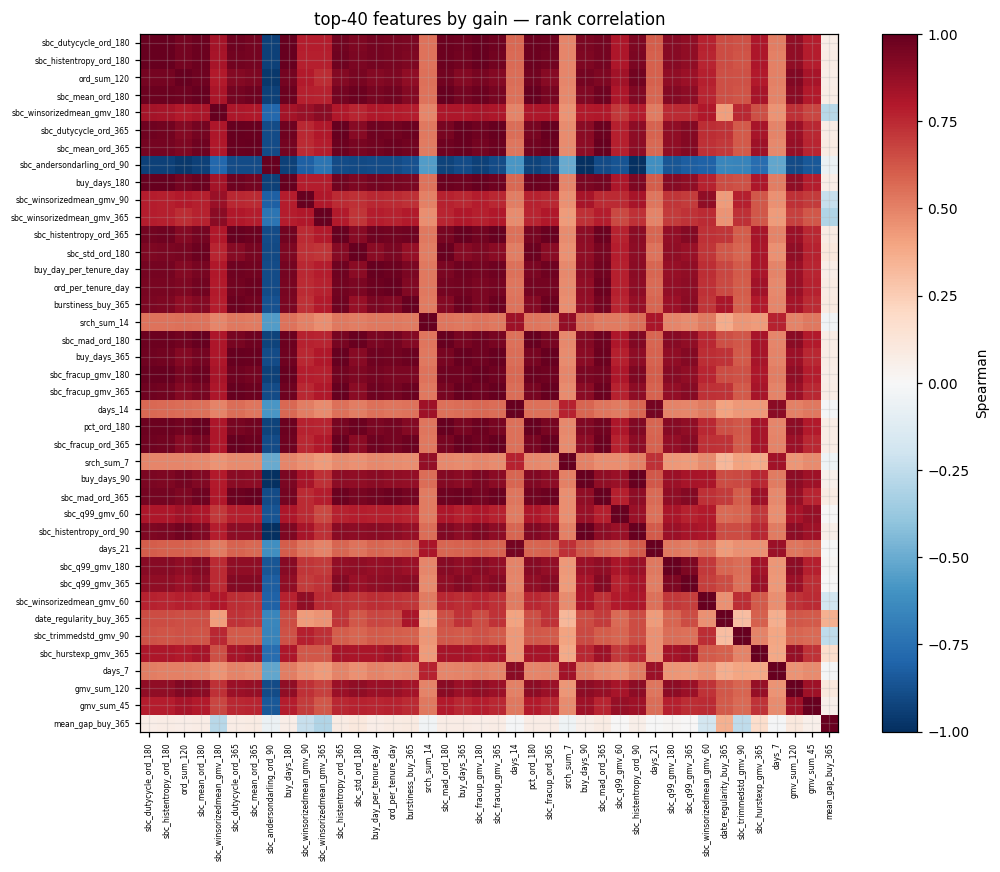

In [32]:
if HAS_EXTRACT:
    K = 40
    sub = df[FEATURES[:K]]
    C = sub.corr(method='spearman').values
    fig, ax = plt.subplots(figsize=(9.5, 8))
    im = ax.imshow(C, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(K)); ax.set_xticklabels(FEATURES[:K], rotation=90, fontsize=5)
    ax.set_yticks(range(K)); ax.set_yticklabels(FEATURES[:K], fontsize=5)
    fig.colorbar(im, fraction=0.046, label='Spearman')
    ax.set_title(f'top-{K} features by gain — rank correlation')
    plt.tight_layout()

    iu = np.triu_indices(K, 1)
    pairs = sorted(zip(np.abs(C[iu]), [(FEATURES[a], FEATURES[b])
                                       for a, b in zip(*iu)]), reverse=True)[:15]
    print('most redundant pairs:')
    for v, (a, b) in pairs:
        print(f'  {v:.3f}  {a}  <->  {b}')

## 11. Single-user explorer

The most useful sanity check there is: pick a user, look at their actual daily series, and see
what the target and features say about them. Re-run for a different `USER_ID`.

try these: [466880, 536774, 866633] | zero-target users: [15, 23, 30]
target (next 30d) : 17,435.35   log1p = 9.766
gmv last 30d      : 23,553.72
orders last 30d   : 48

top features for this user (value, and their percentile in the population):
  sbc_dutycycle_ord_180                         0.289   p 99.0
  sbc_histentropy_ord_180                       1.385   p 99.9
  ord_sum_120                                 144.000   p 99.7
  sbc_mean_ord_180                              1.061   p 99.6
  sbc_winsorizedmean_gmv_180                  315.627   p100.0
  sbc_dutycycle_ord_365                         0.554   p100.0
  sbc_mean_ord_365                              0.952   p 99.6
  sbc_andersondarling_ord_90                    5.315   p  0.0
  buy_days_180                                108.000   p100.0
  sbc_winsorizedmean_gmv_90                   528.501   p100.0
  sbc_winsorizedmean_gmv_365                  264.800   p100.0
  sbc_histentropy_ord_365                       1.322   p 99.

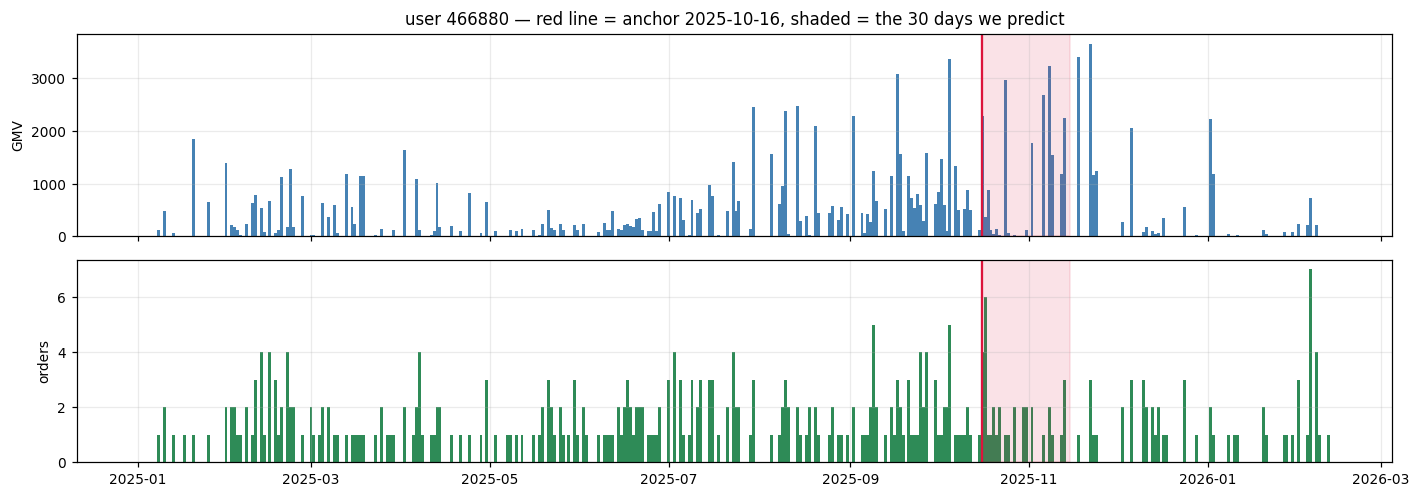

In [33]:
def show_user(user_id, anchor=None):
    anchor = pd.Timestamp(anchor or (meta.get('valid_anchor') if HAS_META else '2025-10-16'))
    u = raw[raw.user_id == user_id].sort_values('event_date')
    if u.empty:
        print('no events for that user'); return
    fig, ax = plt.subplots(2, 1, figsize=(13, 4.6), sharex=True)
    ax[0].bar(u.event_date, u.gmv, width=1.0, color='steelblue'); ax[0].set_ylabel('GMV')
    ax[1].bar(u.event_date, u.to_ord, width=1.0, color='seagreen'); ax[1].set_ylabel('orders')
    for a in ax:
        a.axvline(anchor, color='crimson', lw=1.5)
        a.axvspan(anchor, anchor + pd.Timedelta(days=30), color='crimson', alpha=0.12)
    ax[0].set_title(f'user {user_id} — red line = anchor {anchor.date()}, '
                    f'shaded = the 30 days we predict')
    plt.tight_layout()

    if HAS_EXTRACT and (df.user_id == user_id).any():
        r = df[df.user_id == user_id].iloc[0]
        print(f"target (next 30d) : {r.target:,.2f}   log1p = {r.logt:.3f}")
        print(f"gmv last 30d      : {r.gmv_last30:,.2f}")
        print(f"orders last 30d   : {r.ord_last30:,.0f}")
        print('\ntop features for this user (value, and their percentile in the population):')
        for f in FEATURES[:12]:
            pct = (df[f] < r[f]).mean()
            print(f'  {f:38s} {r[f]:>12,.3f}   p{pct * 100:>5.1f}')

# a heavy buyer, a light one, and a churner
if HAS_EXTRACT:
    cand = df.sort_values('gmv_last30', ascending=False)
    print('try these:', cand.user_id.head(3).tolist(),
          '| zero-target users:', df[df.target <= 0].user_id.head(3).tolist())
    show_user(int(cand.user_id.iloc[0]))

---
### Where to go next

* `DATA.md` — the full EDA writeup: inclusion rule, metric decomposition, headroom, noise floor
* `EXPERIMENTS.md` — current best, LB history, what has been killed and why
* `BACKLOG.md` — ranked ideas, and the graveyard so nothing gets re-run

If you find something here worth acting on, it becomes a config in `configs/` and a run through
`src/run.py` — **not** a number produced in this notebook.

## 12. Hypothesis testing — `my_hypothesis.txt`

Three claims, each turned into a measurement. Two die, one survives in a narrower form.

### 12.1 Is the year-on-year growth real, and can it be used?

The plots in §3 do rise over time. The question is *why*, because the panel's inclusion rule
manufactures exactly this shape: every one of the 250,000 users is **guaranteed** active in each
30-day block after 2025-11-16, and the panel only ever sampled users active at the end — so
anyone who churned during 2025 is absent. Both effects inflate any year-on-year ratio.


active users : 2025 190,797 of 250,000 (76.3%)   2026 250,000 (100.0%)  <- forced to 100% by the guard zone
naive ratio            x1.460   (confounded)
per active user        x1.114
INTENSIVE MARGIN       x1.154   <- the honest number, ~+15%
share spending more in 2026: 54.0%


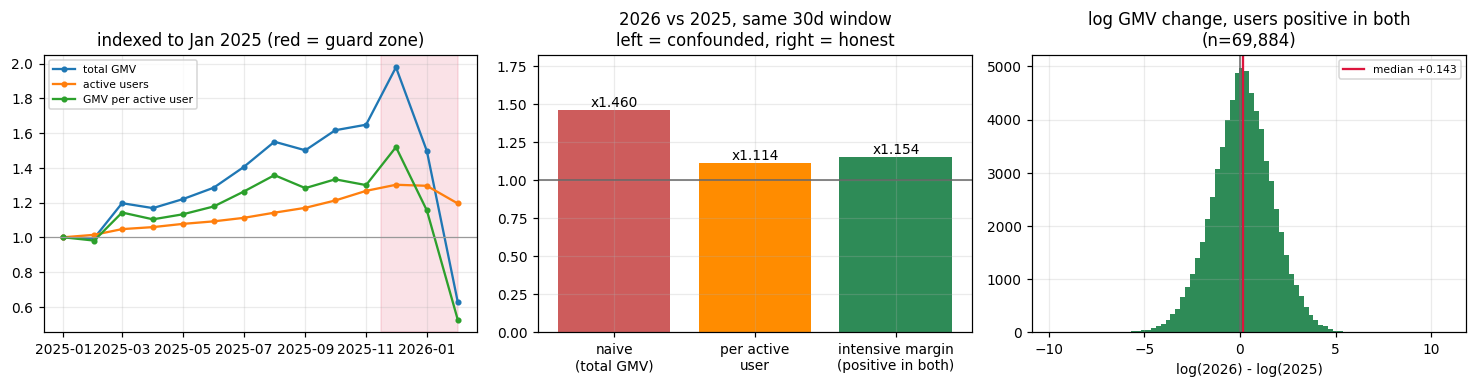

In [34]:
# --- 12.1  year-on-year growth, decomposed ------------------------------------------------
GUARD = pd.Timestamp('2025-11-16')

def window_gmv(a, b):
    m = raw[(raw.event_date >= a) & (raw.event_date <= b)]
    return m.groupby('user_id').gmv.sum()

# the 30 days before each anchor, one year apart -- both fully observed
A = window_gmv('2025-01-15', '2025-02-13')
B = window_gmv('2026-01-15', '2026-02-13')

naive_ratio    = B.sum() / A.sum()
per_active     = (B.sum() / len(B)) / (A.sum() / len(A))
pa, pb         = A[A > 0], B[B > 0]
both           = pa.index.intersection(pb.index)          # positive in BOTH -> intensive margin
r_log          = np.log(B[both].values) - np.log(A[both].values)
intensive      = float(np.exp(np.median(r_log)))

fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.6))

m = raw.groupby(raw.event_date.dt.to_period('M')).agg(gmv=('gmv', 'sum'),
                                                      users=('user_id', 'nunique'))
m['per_active'] = m.gmv / m.users
xs = [p.to_timestamp() for p in m.index]
ax[0].plot(xs, m.gmv / m.gmv.iloc[0], 'o-', ms=3, label='total GMV')
ax[0].plot(xs, m.users / m.users.iloc[0], 'o-', ms=3, label='active users')
ax[0].plot(xs, m.per_active / m.per_active.iloc[0], 'o-', ms=3, label='GMV per active user')
ax[0].axvspan(GUARD, max(xs), color='crimson', alpha=0.12)
ax[0].axhline(1, color='0.6', lw=0.8)
ax[0].set_title('indexed to Jan 2025 (red = guard zone)'); ax[0].legend(fontsize=7)

bars = ['naive\n(total GMV)', 'per active\nuser', 'intensive margin\n(positive in both)']
vals = [naive_ratio, per_active, intensive]
cols = ['indianred', 'darkorange', 'seagreen']
ax[1].bar(bars, vals, color=cols)
ax[1].axhline(1.0, color='0.4', lw=1)
for i, v in enumerate(vals):
    ax[1].text(i, v + 0.02, f'x{v:.3f}', ha='center', fontsize=9)
ax[1].set_ylim(0, max(vals) * 1.25)
ax[1].set_title('2026 vs 2025, same 30d window\nleft = confounded, right = honest')

ax[2].hist(r_log, bins=80, color='seagreen')
ax[2].axvline(0, color='0.4', lw=1)
ax[2].axvline(np.median(r_log), color='crimson', lw=1.5,
              label=f'median {np.median(r_log):+.3f}')
ax[2].set_title(f'log GMV change, users positive in both\n(n={len(both):,})')
ax[2].set_xlabel('log(2026) - log(2025)'); ax[2].legend(fontsize=7)
plt.tight_layout()

print(f'active users : 2025 {len(A):,} of 250,000 ({len(A)/250000:.1%})   '
      f'2026 {len(B):,} ({len(B)/250000:.1%})  <- forced to 100% by the guard zone')
print(f'naive ratio            x{naive_ratio:.3f}   (confounded)')
print(f'per active user        x{per_active:.3f}')
print(f'INTENSIVE MARGIN       x{intensive:.3f}   <- the honest number, ~+15%')
print(f'share spending more in 2026: {(r_log > 0).mean():.1%}')

**Verdict: growth is real but ~+15%, not ~+100%** — and the naive ratio (×1.46) is mostly the
guard zone dragging users from zero to positive.

More importantly it **cannot be monetised by rescaling**, because RMSLE in log space is almost
entirely a correlation metric. The cell below sweeps a global multiplier over the OOF
predictions and shows the level term is worth ~0.01% of the score.

baseline OOF RMSLE 1.76500   optimal k = 0.990 -> 1.76497 (delta -0.00003, i.e. noise)
applying the real +15.4% growth: 1.76974 (delta +0.00474)

-> the level term is ~0% of the metric. The features already carry the level.


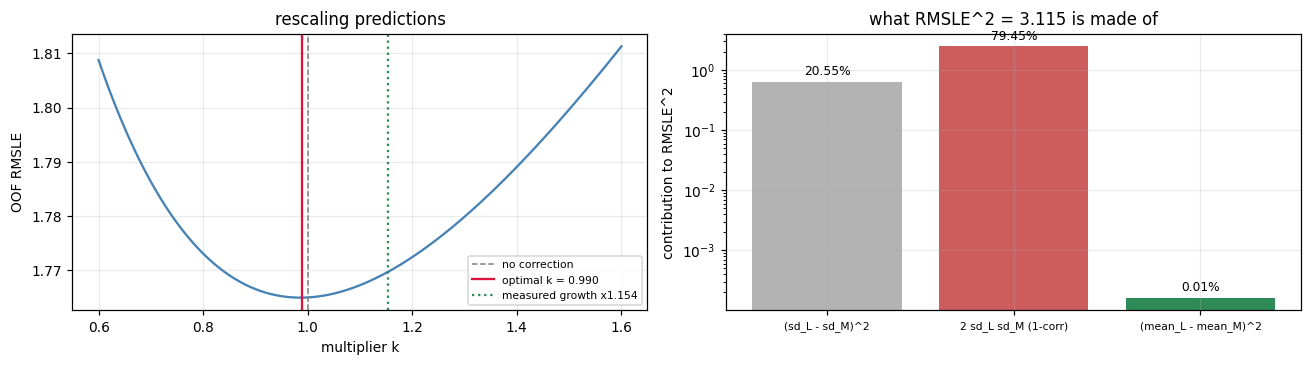

In [35]:
# --- 12.2  can a growth multiplier help? ---------------------------------------------------
oof = pd.read_parquet('reports/e0049.parquet')     # frozen-fold OOF of the best LightGBM
y, p = oof.y_true.values, oof.y_pred.values
base = rmsle(y, p)

ks = np.linspace(0.6, 1.6, 101)
rs = np.array([rmsle(y, p * k) for k in ks])
kstar = ks[int(np.argmin(rs))]

L, M = np.log1p(y), np.log1p(np.maximum(p, 0))
term_mean = (L.mean() - M.mean()) ** 2

fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
ax[0].plot(ks, rs, color='steelblue')
ax[0].axvline(1.0, color='0.5', ls='--', lw=1, label='no correction')
ax[0].axvline(kstar, color='crimson', lw=1.5, label=f'optimal k = {kstar:.3f}')
ax[0].axvline(1.154, color='seagreen', ls=':', lw=1.5, label='measured growth x1.154')
ax[0].set_xlabel('multiplier k'); ax[0].set_ylabel('OOF RMSLE')
ax[0].set_title('rescaling predictions'); ax[0].legend(fontsize=7)

d = decompose(y, p)
parts = [d['term_sd'], d['term_corr'], d['term_mean']]
ax[1].bar(['(sd_L - sd_M)^2', '2 sd_L sd_M (1-corr)', '(mean_L - mean_M)^2'], parts,
          color=['0.7', 'indianred', 'seagreen'])
ax[1].set_yscale('log'); ax[1].set_ylabel('contribution to RMSLE^2')
for i, v in enumerate(parts):
    ax[1].text(i, v * 1.3, f'{100*v/base**2:.2f}%', ha='center', fontsize=8)
ax[1].set_title(f'what RMSLE^2 = {base**2:.3f} is made of')
plt.setp(ax[1].get_xticklabels(), fontsize=7)
plt.tight_layout()

print(f'baseline OOF RMSLE {base:.5f}   optimal k = {kstar:.3f} -> {rs.min():.5f} '
      f'(delta {rs.min()-base:+.5f}, i.e. noise)')
print(f'applying the real +15.4% growth: {rmsle(y, p*1.154):.5f} (delta {rmsle(y,p*1.154)-base:+.5f})')
print('\n-> the level term is ~0% of the metric. The features already carry the level.')

### 12.3 Should we predict 0 for inactive users?

The prize is enormous — an oracle that knew the zeros exactly scores **1.339** against our 1.765.
The catch is that the trade is violently asymmetric: predicting `0.5` instead of `0` for a true
zero costs only `log1p(0.5) = 0.405`, while wrongly zeroing a real buyer costs the whole
`log1p(y)`. So the classifier has to be near-perfect before it pays.

 threshold  % zeroed   truly 0     RMSLE     delta
      0.25     0.2%    95.7%   1.76501  +0.00001
      0.50     5.2%    91.2%   1.76658  +0.00158
      1.00    15.3%    87.5%   1.77434  +0.00934
      2.00    26.0%    82.8%   1.79735  +0.03235
      3.00    32.8%    79.3%   1.82585  +0.06085
      5.00    42.0%    74.4%   1.88718  +0.12218
      8.00    50.5%    69.8%   1.97462  +0.20962
     12.00    57.7%    65.9%   2.07469  +0.30969
     20.00    66.5%    61.1%   2.23367  +0.46867

oracle (perfect zero knowledge) = 1.33910, delta -0.42590
-> huge prize, but even at 91% precision the sweep loses. Same reason the hurdle died.


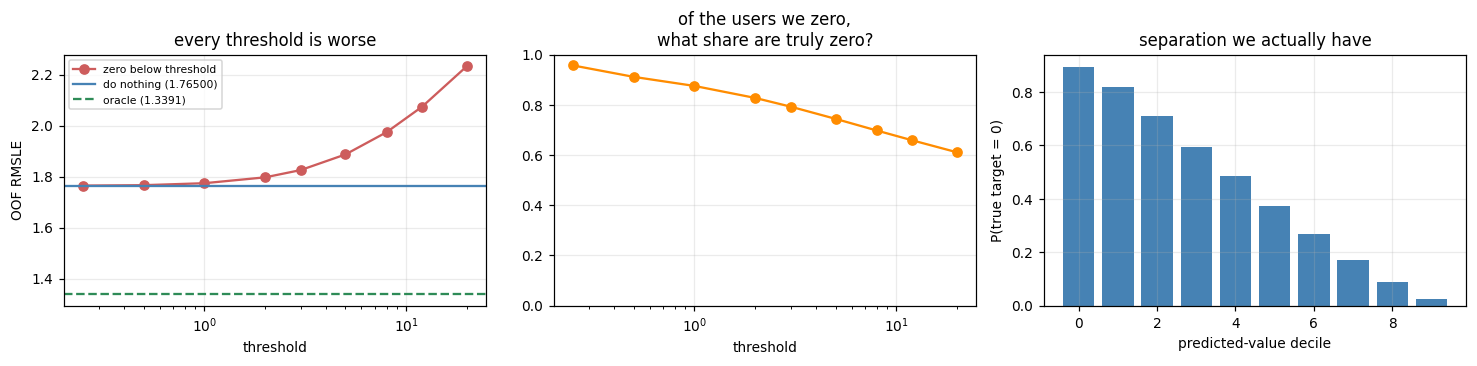

In [36]:
# --- 12.3  zero-thresholding sweep ---------------------------------------------------------
ths = np.array([0.25, 0.5, 1, 2, 3, 5, 8, 12, 20])
res, prec, frac = [], [], []
for t in ths:
    msk = p < t
    res.append(rmsle(y, np.where(msk, 0.0, p)))
    prec.append((y[msk] <= 0).mean() if msk.any() else np.nan)
    frac.append(msk.mean())
res, prec, frac = map(np.array, (res, prec, frac))
oracle = rmsle(y, np.where(y <= 0, 0.0, p))

fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.4))
ax[0].plot(ths, res, 'o-', color='indianred', label='zero below threshold')
ax[0].axhline(base, color='steelblue', lw=1.5, label=f'do nothing ({base:.5f})')
ax[0].axhline(oracle, color='seagreen', ls='--', lw=1.5, label=f'oracle ({oracle:.4f})')
ax[0].set_xscale('log'); ax[0].set_xlabel('threshold'); ax[0].set_ylabel('OOF RMSLE')
ax[0].set_title('every threshold is worse'); ax[0].legend(fontsize=7)

ax[1].plot(ths, prec, 'o-', color='darkorange')
ax[1].set_xscale('log'); ax[1].set_ylim(0, 1); ax[1].set_xlabel('threshold')
ax[1].set_title('of the users we zero,\nwhat share are truly zero?')

dec = np.clip(np.searchsorted(np.quantile(p, np.linspace(0, 1, 11)), p) - 1, 0, 9)
pz = [(y[dec == i] <= 0).mean() for i in range(10)]
ax[2].bar(range(10), pz, color='steelblue')
ax[2].set_xlabel('predicted-value decile'); ax[2].set_ylabel('P(true target = 0)')
ax[2].set_title('separation we actually have')
plt.tight_layout()

print(f'{"threshold":>10} {"% zeroed":>9} {"truly 0":>9} {"RMSLE":>9} {"delta":>9}')
for t, f_, pr, r in zip(ths, frac, prec, res):
    print(f'{t:>10.2f} {f_:>8.1%} {pr:>8.1%} {r:>9.5f} {r-base:>+9.5f}')
print(f'\noracle (perfect zero knowledge) = {oracle:.5f}, delta {oracle-base:+.5f}')
print('-> huge prize, but even at 91% precision the sweep loses. Same reason the hurdle died.')

### 12.4 The two branches in the pair grid

`sbc_histentropy_ord_180` vs `sbc_mean_ord_180` really do split into two clouds. The split turns
out to be exactly **"zero orders in the last 180 days"** — and `ord_last30`, `buy_days_180` and
`gmv_last30` are all already features that are exactly zero there, so a branch indicator carries
no information the GBDT cannot already reach.

                           branch A     branch B
  mean ord_last30              0.000        3.665
  mean gmv_last30              0.000      123.927
  mean buy_days_180            0.000       11.087

-> branch A is identically zero on every activity feature. Already visible to the model.


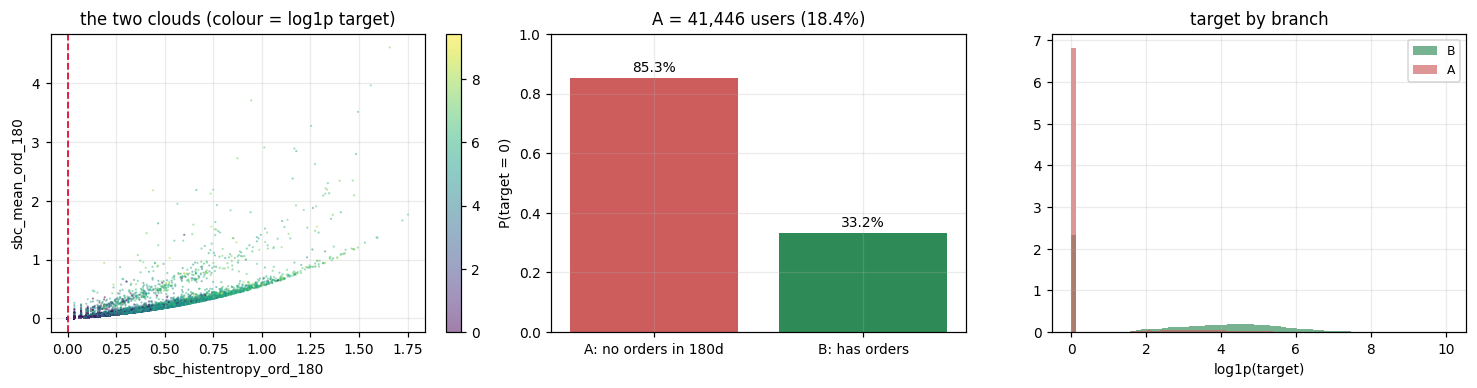

In [37]:
# --- 12.4  what separates the branches? ----------------------------------------------------
fa, fb = 'sbc_histentropy_ord_180', 'sbc_mean_ord_180'
xa, xb = df[fa].values, df[fb].values
branch_A = xa <= 1e-9

fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.6))
s = np.random.default_rng(0).choice(len(df), 25000, replace=False)
sc = ax[0].scatter(xa[s], xb[s], c=df.logt.values[s], s=2, cmap=CMAP, linewidths=0, alpha=0.5)
ax[0].axvline(1e-9, color='crimson', lw=1.2, ls='--')
ax[0].set_xlabel(fa); ax[0].set_ylabel(fb)
ax[0].set_title('the two clouds (colour = log1p target)')
fig.colorbar(sc, ax=ax[0], fraction=0.046)

lbl = ['A: no orders in 180d', 'B: has orders']
ax[1].bar(lbl, [(df.target.values[branch_A] <= 0).mean(),
                (df.target.values[~branch_A] <= 0).mean()], color=['indianred', 'seagreen'])
ax[1].set_ylabel('P(target = 0)'); ax[1].set_ylim(0, 1)
for i, v in enumerate([(df.target.values[branch_A] <= 0).mean(),
                       (df.target.values[~branch_A] <= 0).mean()]):
    ax[1].text(i, v + 0.02, f'{v:.1%}', ha='center')
ax[1].set_title(f'A = {branch_A.sum():,} users ({branch_A.mean():.1%})')

ax[2].hist(df.logt.values[~branch_A], bins=70, alpha=0.65, label='B', color='seagreen', density=True)
ax[2].hist(df.logt.values[branch_A], bins=70, alpha=0.65, label='A', color='indianred', density=True)
ax[2].set_xlabel('log1p(target)'); ax[2].set_title('target by branch'); ax[2].legend(fontsize=8)
plt.tight_layout()

print(f'{"":22s} {"branch A":>12s} {"branch B":>12s}')
for c in ['ord_last30', 'gmv_last30', 'buy_days_180']:
    if c in df.columns:
        print(f'  mean {c:16s} {df[c].values[branch_A].mean():>12.3f} '
              f'{df[c].values[~branch_A].mean():>12.3f}')
print('\n-> branch A is identically zero on every activity feature. Already visible to the model.')